In [2]:
from argopy import DataFetcher
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load BGC dataset for float 2903886
ds = DataFetcher(mode="expert", ds="bgc").float(2903886).load().data

print("Variables:", list(ds.variables))

# Make sure time is in datetime format
time = pd.to_datetime(ds['TIME'].values)

# Create masks
surface_mask = ds['PRES'] <= 10  # Surface: <= 10 dbar
june_2025_mask = (time >= "2025-06-01") & (time < "2025-07-01")

# Apply both masks together
mask = surface_mask & june_2025_mask

# Get QC values for BBP700 at surface in June 2025
qc_surface = ds['BBP700_ADJUSTED_QC'].where(mask, drop=True)
qc_vals = np.array(qc_surface.values).astype(str)

# Summarize QC flags
unique, counts = np.unique(qc_vals, return_counts=True)
qc_summary = dict(zip(unique, counts))

print("QC flag summary for BBP700 near surface (<=10 dbar) in June 2025:")
for flag, cnt in qc_summary.items():
    print(f"QC={flag}: {cnt} points")

/opt/anaconda3/envs/earthaccess-env/lib/python3.11/site-packages/argopy/xarray.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self._dims = list(xarray_obj.dims.keys())


Variables: ['BBP700', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_ERROR', 'BBP700_ADJUSTED_QC', 'BBP700_DATA_MODE', 'BBP700_QC', 'CDOM', 'CDOM_ADJUSTED', 'CDOM_ADJUSTED_ERROR', 'CDOM_ADJUSTED_QC', 'CDOM_DATA_MODE', 'CDOM_QC', 'CHLA', 'CHLA_ADJUSTED', 'CHLA_ADJUSTED_ERROR', 'CHLA_ADJUSTED_QC', 'CHLA_DATA_MODE', 'CHLA_QC', 'CONFIG_MISSION_NUMBER', 'CYCLE_NUMBER', 'DIRECTION', 'DOWN_IRRADIANCE380', 'DOWN_IRRADIANCE380_ADJUSTED', 'DOWN_IRRADIANCE380_ADJUSTED_ERROR', 'DOWN_IRRADIANCE380_ADJUSTED_QC', 'DOWN_IRRADIANCE380_DATA_MODE', 'DOWN_IRRADIANCE380_QC', 'DOWN_IRRADIANCE443', 'DOWN_IRRADIANCE443_ADJUSTED', 'DOWN_IRRADIANCE443_ADJUSTED_ERROR', 'DOWN_IRRADIANCE443_ADJUSTED_QC', 'DOWN_IRRADIANCE443_DATA_MODE', 'DOWN_IRRADIANCE443_QC', 'DOWN_IRRADIANCE490', 'DOWN_IRRADIANCE490_ADJUSTED', 'DOWN_IRRADIANCE490_ADJUSTED_ERROR', 'DOWN_IRRADIANCE490_ADJUSTED_QC', 'DOWN_IRRADIANCE490_DATA_MODE', 'DOWN_IRRADIANCE490_QC', 'DOWN_IRRADIANCE555', 'DOWN_IRRADIANCE555_ADJUSTED', 'DOWN_IRRADIANCE555_ADJUSTED_ERROR'

In [14]:
# Find indices where mask is True
matching_indices = np.where(mask)[0]

# Get the first matching profile's cycle number
first_cycle = ds['CYCLE_NUMBER'].values[matching_indices[0]]

print("Selected cycle:", first_cycle)

# Create mask for that specific profile (entire depth range, not just surface)
profile_mask = ds['CYCLE_NUMBER'] == first_cycle

# Extract data for that profile
profile_data = ds.where(profile_mask, drop=True)

print("Profile date:", pd.to_datetime(profile_data['TIME'].values[0]))
print("Variables in profile:", list(profile_data.variables))


Selected cycle: 90
Profile date: 2025-06-08 19:17:50.002000128
Variables in profile: ['BBP700', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_ERROR', 'BBP700_ADJUSTED_QC', 'BBP700_DATA_MODE', 'BBP700_QC', 'CDOM', 'CDOM_ADJUSTED', 'CDOM_ADJUSTED_ERROR', 'CDOM_ADJUSTED_QC', 'CDOM_DATA_MODE', 'CDOM_QC', 'CHLA', 'CHLA_ADJUSTED', 'CHLA_ADJUSTED_ERROR', 'CHLA_ADJUSTED_QC', 'CHLA_DATA_MODE', 'CHLA_QC', 'CONFIG_MISSION_NUMBER', 'CYCLE_NUMBER', 'DIRECTION', 'DOWN_IRRADIANCE380', 'DOWN_IRRADIANCE380_ADJUSTED', 'DOWN_IRRADIANCE380_ADJUSTED_ERROR', 'DOWN_IRRADIANCE380_ADJUSTED_QC', 'DOWN_IRRADIANCE380_DATA_MODE', 'DOWN_IRRADIANCE380_QC', 'DOWN_IRRADIANCE443', 'DOWN_IRRADIANCE443_ADJUSTED', 'DOWN_IRRADIANCE443_ADJUSTED_ERROR', 'DOWN_IRRADIANCE443_ADJUSTED_QC', 'DOWN_IRRADIANCE443_DATA_MODE', 'DOWN_IRRADIANCE443_QC', 'DOWN_IRRADIANCE490', 'DOWN_IRRADIANCE490_ADJUSTED', 'DOWN_IRRADIANCE490_ADJUSTED_ERROR', 'DOWN_IRRADIANCE490_ADJUSTED_QC', 'DOWN_IRRADIANCE490_DATA_MODE', 'DOWN_IRRADIANCE490_QC', 'DOWN_IRRADIAN

In [30]:
from datetime import datetime
import pytz

# Coordinates
lat = 31.78949
lon = -120.59814

# UTC datetime (year/month/day must be specified)
utc_time_str = "2025-06-08 19:17:50"
utc_dt = datetime.strptime(utc_time_str, "%Y-%m-%d %H:%M:%S")

# Timezones
utc_zone = pytz.utc
pacific_zone = pytz.timezone("US/Pacific")

# Localize to UTC first
utc_dt = utc_zone.localize(utc_dt)

# Convert to Pacific local time
local_dt = utc_dt.astimezone(pacific_zone)

print("UTC time:", utc_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("Local time:", local_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))

UTC time: 2025-06-08 19:17:50 UTC
Local time: 2025-06-08 12:17:50 PDT


In [53]:
# Extract depth and BBP700 for the selected profile
depth = profile_data["PRES_ADJUSTED"].values
bbp700 = profile_data["BBP700_ADJUSTED"].values

# Some profiles may be stored 2D [n_profiles, n_levels]
# If so, take the first (and only) profile slice
if bbp700.ndim > 1:
    depth = depth[0, :]
    bbp700 = bbp700[0, :]

# Remove NaN values
mask = ~np.isnan(bbp700)
depth = depth[mask]
bbp700 = bbp700[mask]

print("Number of depth levels:", len(depth))
print("First 10 BBP700 values:", bbp700[:10])

Number of depth levels: 1585
First 10 BBP700 values: [9.9999000e+04 9.9999000e+04 9.9999000e+04 9.9999000e+04 9.9999000e+04
 5.7446904e-04 9.9999000e+04 9.9999000e+04 9.9999000e+04 8.6719991e-04]


In [55]:
depth = profile_data["PRES_ADJUSTED"].values
bbp700 = profile_data["BBP700_ADJUSTED"].values

# Replace fill values with NaN
bbp700 = np.where(bbp700 > 1e4, np.nan, bbp700)

# Drop NaNs
valid_mask = ~np.isnan(bbp700)
depth = depth[valid_mask]
bbp700 = bbp700[valid_mask]

print("Number of valid BBP700 points:", len(bbp700))
print("First 10 valid values:", bbp700[:10])

Number of valid BBP700 points: 247
First 10 valid values: [0.00057447 0.0008672  0.000652   0.00072981 0.00081928 0.00119353
 0.00098828 0.00094979 0.00099948 0.00097831]


In [61]:
# Use adjusted if available, otherwise raw
if np.isfinite(profile_data["PRES_ADJUSTED"].values).any():
    depth = profile_data["PRES_ADJUSTED"].values
else:
    depth = profile_data["PRES"].values

bbp700 = profile_data["BBP700_ADJUSTED"].values

# Mask bad BBP values
valid_mask = bbp700 < 1e4
depth_valid = depth[valid_mask]
bbp_valid   = bbp700[valid_mask]

for d, b in zip(depth_valid[:10], bbp_valid[:10]):
    print(f"Depth = {d:.1f} dbar, BBP700 = {b:.6f} m^-1")

Depth = 1.9 dbar, BBP700 = 0.000574 m^-1
Depth = 3.8 dbar, BBP700 = 0.000867 m^-1
Depth = 5.7 dbar, BBP700 = 0.000652 m^-1
Depth = 7.8 dbar, BBP700 = 0.000730 m^-1
Depth = 9.6 dbar, BBP700 = 0.000819 m^-1
Depth = 11.8 dbar, BBP700 = 0.001194 m^-1
Depth = 13.6 dbar, BBP700 = 0.000988 m^-1
Depth = 15.8 dbar, BBP700 = 0.000950 m^-1
Depth = 17.6 dbar, BBP700 = 0.000999 m^-1
Depth = 19.8 dbar, BBP700 = 0.000978 m^-1


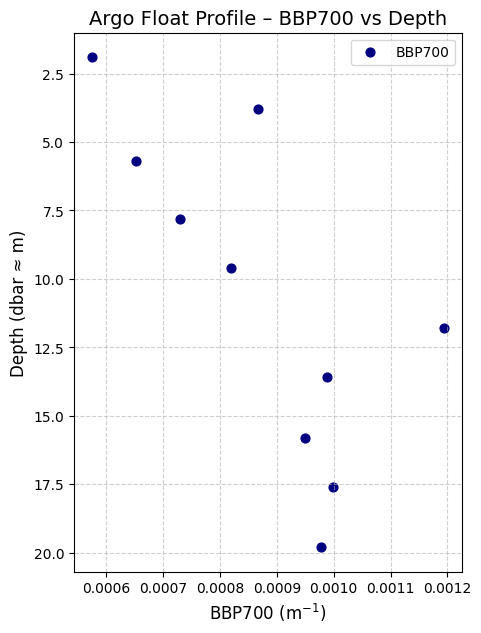

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Example: your extracted values (replace with your full arrays)
depths = np.array([1.9, 3.8, 5.7, 7.8, 9.6, 11.8, 13.6, 15.8, 17.6, 19.8])
bbp700 = np.array([0.000574, 0.000867, 0.000652, 0.000730, 0.000819,
                   0.001194, 0.000988, 0.000950, 0.000999, 0.000978])

# Plot as scatter points only
plt.figure(figsize=(5,7))
plt.scatter(bbp700, depths, color='navy', s=40, label="BBP700")

# Flip y-axis so surface is at top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("BBP700 (m$^{-1}$)", fontsize=12)
plt.ylabel("Depth (dbar ≈ m)", fontsize=12)
plt.title("Argo Float Profile – BBP700 vs Depth", fontsize=14)

# Add grid + legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [33]:
import requests

pace_url = "https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"

# Download file locally
pace_filename = "PACE_OCI_20250608.nc"
with requests.get(pace_url, stream=True) as r:
    r.raise_for_status()
    with open(pace_filename, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print("PACE file downloaded:", pace_filename)

PACE file downloaded: PACE_OCI_20250608.nc


In [34]:
import xarray as xr

ds_pace = xr.open_dataset(pace_filename)
print(ds_pace)


<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20250608T211127.L2.OC_BGC.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data20/sdpsoper/vdc/vpu19/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -113.81133
    geospatial_lon_min:                -149.15231
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9704912304878235


In [36]:
from argopy import DataFetcher
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Load BGC dataset for float 2903886 ---
ds = DataFetcher(mode="expert", ds="bgc").float(2903886).load().data

# --- Convert time to datetime ---
time = pd.to_datetime(ds['TIME'].values)

# --- Pick the exact cycle/profile (cycle 90) ---
cycle_number = 90
mask_cycle = ds['CYCLE_NUMBER'] == cycle_number

# --- Optional: surface only (<=10 dbar) ---
surface_mask = ds['PRES'] <= 10

# --- Combine masks ---
mask = mask_cycle & surface_mask

# --- Extract BBP700_ADJUSTED and depth ---
bbp_argo = ds['BBP700_ADJUSTED'].where(mask, drop=True).values
depth_argo = ds['PRES'].where(mask, drop=True).values

# --- Inspect ---
print("ARGO BBP700_ADJUSTED values (surface, cycle 90):", bbp_argo)
print("Corresponding depths:", depth_argo)

/opt/anaconda3/envs/earthaccess-env/lib/python3.11/site-packages/argopy/xarray.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self._dims = list(xarray_obj.dims.keys())


ARGO BBP700_ADJUSTED values (surface, cycle 90): [9.9999000e+04 9.9999000e+04 9.9999000e+04 9.9999000e+04 9.9999000e+04
 5.7446904e-04 9.9999000e+04 9.9999000e+04 9.9999000e+04 8.6719991e-04
 9.9999000e+04 9.9999000e+04 9.9999000e+04 6.5199862e-04 9.9999000e+04
 9.9999000e+04 9.9999000e+04 7.2981499e-04 9.9999000e+04 9.9999000e+04
 9.9999000e+04 8.1927748e-04]
Corresponding depths: [0.6  0.76 0.84 0.96 1.04 1.92 2.   2.8  3.   3.76 4.08 4.72 5.   5.72
 5.96 6.72 7.04 7.76 8.04 8.76 9.   9.56]


In [37]:
import requests

# PACE granule URL (your updated date)
pace_url = "https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"
pace_filename = "PACE_20250608.nc"

# Download the file locally
with requests.get(pace_url, stream=True) as r:
    r.raise_for_status()
    with open(pace_filename, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

print("PACE file downloaded:", pace_filename)

PACE file downloaded: PACE_20250608.nc


In [38]:
import xarray as xr
import numpy as np

# Open the downloaded PACE granule
ds_pace = xr.open_dataset("PACE_20250608.nc")

# See all variables in the dataset
print(ds_pace)

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20250608T211127.L2.OC_BGC.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data20/sdpsoper/vdc/vpu19/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -113.81133
    geospatial_lon_min:                -149.15231
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9704912304878235


In [48]:
import earthaccess

earthaccess.login() 

granule_url = "https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"
local_file = earthaccess.download(granule_url)
print("Downloaded file:", local_file)

QUEUEING TASKS | : 100%|█████████████████████████| 1/1 [00:00<00:00, 224.21it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:03<00:00,  3.61s/it]
COLLECTING RESULTS | : 100%|████████████████████| 1/1 [00:00<00:00, 9020.01it/s]

Downloaded file: ['/Users/allie/data/2025-08-15-6b3b99/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc']


In [47]:
import xarray as xr

local_file = "/Users/allie/data/2025-08-15-f16a34/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"
ds_pace = xr.open_dataset(local_file, engine="h5netcdf")

print(ds_pace)

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20250608T211127.L2.OC_BGC.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data20/sdpsoper/vdc/vpu19/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -113.81133
    geospatial_lon_min:                -149.15231
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9704912304878235


In [42]:
import xarray as xr

# If you have a list of files, pick the first one
# local_file = ["PACE_20250608.nc"]  # example
local_file_str = local_file[0] if isinstance(local_file, list) else local_file

# Open the file with netcdf4 engine
ds_pace = xr.open_dataset(local_file_str, engine="netcdf4")

# Inspect variables
print(ds_pace)

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20250608T211127.L2.OC_BGC.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data20/sdpsoper/vdc/vpu19/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -113.81133
    geospatial_lon_min:                -149.15231
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9704912304878235


In [43]:
print(list(ds_pace.data_vars))


[]


In [65]:
import earthaccess
import xarray as xr
from datetime import datetime, timedelta

# ARGO profile info
argo_time = datetime(2025, 6, 8, 19, 17, 50)
lat, lon = 31.78949, -120.59814

start_time = (argo_time - timedelta(days=1)).strftime("%Y-%m-%dT%H:%M:%SZ")
end_time   = (argo_time + timedelta(days=1)).strftime("%Y-%m-%dT%H:%M:%SZ")

# Bounding box around ARGO float
bbox = (lon-0.5, lat-0.5, lon+0.5, lat+0.5)

# Search PACE OCI BGC NRT granules
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    temporal=(start_time, end_time),
    bounding_box=bbox
)

print(f"Granules found: {len(results)}")

# Try opening each granule and check for BBP700
for granule in results:
    try:
        ds = xr.open_dataset(granule.urls[0], engine="h5netcdf")
        if "BBP700" in ds.variables or "BBP700_ADJUSTED" in ds.variables:
            print("Found granule with BBP700:", granule.urls[0])
            ds_pace = ds  # Save this dataset
            break
        else:
            print("Granule has no BBP700:", granule.urls[0])
    except Exception as e:
        print("Failed to open granule:", granule.urls[0], e)


Granules found: 2


AttributeError: 'DataGranule' object has no attribute 'urls'

In [46]:
import xarray as xr
import earthaccess

ds_pace = None

for granule in results:
    try:
        # Open the granule via earthaccess (returns a file-like object)
        file_obj = earthaccess.open(granule)  # no .urls
        # Load into xarray with h5netcdf engine
        ds = xr.open_dataset(file_obj, engine="h5netcdf")
        
        # Check if BBP700 is present
        if "BBP700" in ds.variables or "BBP700_ADJUSTED" in ds.variables:
            print("Found granule with BBP700")
            ds_pace = ds
            break
        else:
            print("Granule has no BBP700")
    except Exception as e:
        print("Failed to open granule:", e)

if ds_pace is not None:
    print("PACE dataset ready for comparison")
else:
    print("No PACE granule contains backscattering")

Failed to open granule: ('_open: 0 methods found', (<class 'earthaccess.store.Store'>, <class 'earthaccess.results.DataGranule'>, <class 'NoneType'>), set())
Failed to open granule: ('_open: 0 methods found', (<class 'earthaccess.store.Store'>, <class 'earthaccess.results.DataGranule'>, <class 'NoneType'>), set())
Failed to open granule: ('_open: 0 methods found', (<class 'earthaccess.store.Store'>, <class 'earthaccess.results.DataGranule'>, <class 'NoneType'>), set())
Failed to open granule: ('_open: 0 methods found', (<class 'earthaccess.store.Store'>, <class 'earthaccess.results.DataGranule'>, <class 'NoneType'>), set())
Failed to open granule: ('_open: 0 methods found', (<class 'earthaccess.store.Store'>, <class 'earthaccess.results.DataGranule'>, <class 'NoneType'>), set())
No PACE granule contains backscattering


In [68]:
import xarray as xr
import matplotlib.pyplot as plt

# Path to your downloaded PACE file
local_file = "PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"

# Open dataset
ds = xr.open_dataset(local_file)

# Print available variables to see what bbp wavelengths are in the file
print("Available variables:", list(ds.data_vars.keys()))

# --- Pick bbp700 if available ---
if "bbp_700" in ds.data_vars:
    bbp = ds["bbp_700"]
elif "bbp_671" in ds.data_vars:
    bbp = ds["bbp_671"]  # fallback, close to 700 nm
else:
    raise ValueError("No bbp700 or nearby bbp variable found in this file")

# Extract coordinates
lat = ds["latitude"]
lon = ds["longitude"]

# Example Argo float location (replace with your actual float coords)
argo_lat = 30.0   # <-- put your float latitude here
argo_lon = -140.0 # <-- put your float longitude here

# Plot PACE bbp map
plt.figure(figsize=(9,6))
plt.pcolormesh(lon, lat, bbp, shading="auto")
plt.colorbar(label="bbp [m^-1]")
plt.scatter(argo_lon, argo_lat, color="red", marker="x", s=100, label="Argo Float")
plt.legend()
plt.title("PACE bbp near Argo Float (2025-06-08)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/allie/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc'

In [69]:
import earthaccess

granule_url = "https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"
local_file = earthaccess.download(granule_url)

print("File saved at:", local_file)

QUEUEING TASKS | : 100%|█████████████████████████| 1/1 [00:00<00:00, 277.09it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:02<00:00,  2.86s/it]
COLLECTING RESULTS | : 100%|███████████████████| 1/1 [00:00<00:00, 16131.94it/s]

File saved at: ['/Users/allie/data/2025-08-20-7944bb/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc']


In [70]:
import xarray as xr

ds = xr.open_dataset(local_file)
print(ds)

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'argo', 'kerchunk', 'zarr']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [71]:
import os

print("File path:", local_file)
print("File size (bytes):", os.path.getsize(local_file))

# Peek at first 200 characters
with open(local_file, "rb") as f:
    print(f.read(200))

File path: ['/Users/allie/data/2025-08-20-7944bb/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc']


TypeError: stat: path should be string, bytes, os.PathLike or integer, not list

In [72]:
import os

# Take the first element from the list
local_file = local_file[0]

print("File path:", local_file)
print("File size (bytes):", os.path.getsize(local_file))

# Peek at first 200 bytes
with open(local_file, "rb") as f:
    print(f.read(200))


File path: /Users/allie/data/2025-08-20-7944bb/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc
File size (bytes): 10478604
b'\x89HDF\r\n\x1a\n\x02\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\x0c\xe4\x9f\x00\x00\x00\x00\x000\x00\x00\x00\x00\x00\x00\x00i\xbc\xc7\xc0OHDR\x02\x0c\xb4\n\x02\x00\x01\x00\x00\x00\x00\x02"\x00\x00\x00\x00\x00\x03\x0c\x00\x00\x00\x00\x00\x00\x00\x1d\x13\x00\x00\x00\x00\x00\x00\xaf\x13\x00\x00\x00\x00\x00\x00\xd5\x13\x00\x00\x00\x00\x00\x00\x15\x1c\x00\x04\x00\x00\x00\x03.\x00\x15\t\x00\x00\x00\x00\x00\x00\xa7\t\x00\x00\x00\x00\x00\x00\xcd\t\x00\x00\x00\x00\x00\x00\x00\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'


In [73]:
import xarray as xr

ds = xr.open_dataset(local_file, engine="netcdf4")
print(ds)


<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20250608T211127.L2.OC_BGC.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data20/sdpsoper/vdc/vpu19/w...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                -113.81133
    geospatial_lon_min:                -149.15231
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     0.9704912304878235


In [74]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = "/Users/allie/data/2025-08-20-7944bb/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"

# Open HDF5 file
with h5py.File(file_path, 'r') as f:
    # List all groups at top level
    print("Top-level groups:", list(f.keys()))

    # Example: go into 'geophysical_data' or similar group
    # (You may need to adjust depending on actual group names)
    data_group = f['geophysical_data']
    print("Variables in geophysical_data:", list(data_group.keys()))

    # Suppose BBP is called 'bbp_700' in this group:
    bbp700 = data_group['bbp_700'][:]  # all data
    lat = data_group['latitude'][:]
    lon = data_group['longitude'][:]

# Quick plot of BBP700
plt.figure(figsize=(6,4))
plt.scatter(lon, lat, c=bbp700, cmap='viridis', s=10)
plt.colorbar(label='BBP700 (m^-1)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('PACE OCI BBP700')
plt.show()

Top-level groups: ['sensor_band_parameters', 'scan_line_attributes', 'geophysical_data', 'navigation_data', 'processing_control', 'number_of_lines', 'pixels_per_line', 'bands_per_pixel', 'number_of_reflectance_location_values', 'number_of_cloud_phases', 'number_of_bands', 'number_of_reflective_bands']
Variables in geophysical_data: ['chlor_a', 'carbon_phyto', 'poc', 'chlor_a_unc', 'carbon_phyto_unc', 'l2_flags']


KeyError: "Unable to synchronously open object (object 'bbp_700' doesn't exist)"

In [75]:
import h5py

file_path = "/Users/allie/data/2025-08-20-7944bb/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"

with h5py.File(file_path, 'r') as f:
    # Recursively print all groups and datasets
    def print_h5_group(name, obj):
        print(name, "->", type(obj))
    
    f.visititems(print_h5_group)

bands_per_pixel -> <class 'h5py._hl.dataset.Dataset'>
geophysical_data -> <class 'h5py._hl.group.Group'>
geophysical_data/carbon_phyto -> <class 'h5py._hl.dataset.Dataset'>
geophysical_data/carbon_phyto_unc -> <class 'h5py._hl.dataset.Dataset'>
geophysical_data/chlor_a -> <class 'h5py._hl.dataset.Dataset'>
geophysical_data/chlor_a_unc -> <class 'h5py._hl.dataset.Dataset'>
geophysical_data/l2_flags -> <class 'h5py._hl.dataset.Dataset'>
geophysical_data/poc -> <class 'h5py._hl.dataset.Dataset'>
navigation_data -> <class 'h5py._hl.group.Group'>
navigation_data/latitude -> <class 'h5py._hl.dataset.Dataset'>
navigation_data/longitude -> <class 'h5py._hl.dataset.Dataset'>
navigation_data/tilt -> <class 'h5py._hl.dataset.Dataset'>
number_of_bands -> <class 'h5py._hl.dataset.Dataset'>
number_of_cloud_phases -> <class 'h5py._hl.dataset.Dataset'>
number_of_lines -> <class 'h5py._hl.dataset.Dataset'>
number_of_reflectance_location_values -> <class 'h5py._hl.dataset.Dataset'>
number_of_reflective_

In [76]:
with h5py.File(file_path, 'r') as f:
    print(list(f['geophysical_data'].keys()))

['chlor_a', 'carbon_phyto', 'poc', 'chlor_a_unc', 'carbon_phyto_unc', 'l2_flags']


In [79]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Open the granule
filename = "PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.nc"  # replace with your actual file
with h5py.File(filename, "r") as f:
    # Look at available variables
    geophysical = f["geophysical_data"]
    print("Available variables:", list(geophysical.keys()))
    
    # Select one Rrs band, e.g. 443 nm
    rrs = geophysical["Rrs_443"][:]
    lat = f["navigation_data"]["latitude"][:]
    lon = f["navigation_data"]["longitude"][:]

# Mask fill values (PACE uses -32767 or negative for bad data)
rrs = np.ma.masked_where(rrs < 0, rrs)

# Plot
plt.figure(figsize=(8,6))
plt.pcolormesh(lon, lat, rrs, shading="auto", cmap="viridis")
plt.colorbar(label="Rrs(443) [sr^-1]")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("PACE Rrs (443 nm) - 2025-06-08 Granule")
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [80]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Path to your granule
filename = "PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.nc"  # update if different

with h5py.File(filename, "r") as f:
    geophysical = f["geophysical_data"]
    print("Available variables:", list(geophysical.keys()))  # check what's inside
    
    # Pick an Rrs band instead of chlor_a
    rrs = geophysical["Rrs_443"][:]  
    lat = f["navigation_data"]["latitude"][:]
    lon = f["navigation_data"]["longitude"][:]

# Mask invalid values (negative / fill)
rrs = np.ma.masked_where(rrs < 0, rrs)

# Plot
plt.figure(figsize=(8,6))
plt.pcolormesh(lon, lat, rrs, shading="auto", cmap="viridis")
plt.colorbar(label="Rrs(443) [sr^-1]")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("PACE Rrs (443 nm) - 2025-06-08 Granule")
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [81]:
import earthaccess

granule_url = "https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc"
local_file = earthaccess.download(granule_url)
print("Downloaded file:", local_file)

QUEUEING TASKS | : 100%|█████████████████████████| 1/1 [00:00<00:00, 611.59it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:02<00:00,  2.86s/it]
COLLECTING RESULTS | : 100%|███████████████████| 1/1 [00:00<00:00, 12787.51it/s]

Downloaded file: ['/Users/allie/data/2025-08-20-f9dea0/PACE_OCI.20250608T211127.L2.OC_BGC.V3_0.NRT.nc']


In [82]:
import h5py

filename = local_file  # use the variable from download
with h5py.File(filename, "r") as f:
    print(list(f.keys()))

TypeError: expected str, bytes or os.PathLike object, not list

In [83]:
import h5py

# If earthaccess.download() gave you a list
filename = local_file[0]   # take the first file path

with h5py.File(filename, "r") as f:
    print(list(f.keys()))

['sensor_band_parameters', 'scan_line_attributes', 'geophysical_data', 'navigation_data', 'processing_control', 'number_of_lines', 'pixels_per_line', 'bands_per_pixel', 'number_of_reflectance_location_values', 'number_of_cloud_phases', 'number_of_bands', 'number_of_reflective_bands']


In [84]:
import h5py
import matplotlib.pyplot as plt

filename = local_file[0]  # use first element of the list

with h5py.File(filename, "r") as f:
    geophysical = f["geophysical_data"]
    print("Variables in geophysical_data:", list(geophysical.keys()))

Variables in geophysical_data: ['chlor_a', 'carbon_phyto', 'poc', 'chlor_a_unc', 'carbon_phyto_unc', 'l2_flags']


In [85]:
import earthaccess

# login
earthaccess.login()

# Search for OCI L2 OC product
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_OC",
    temporal=("2025-06-08T21:11:00", "2025-06-08T21:12:00"),  # narrow window
    count=10
)

print("Granules found:", len(results))
for r in results:
    print(r.data_links())

# Download first match
granule_file = earthaccess.download(results[0])
print("Downloaded:", granule_file)

Granules found: 0


IndexError: list index out of range

In [87]:
import earthaccess
import xarray as xr
from datetime import datetime, timedelta

# ARGO profile info
argo_time = datetime(2025, 6, 8, 19, 17, 50)
lat, lon = 31.78949, -120.59814

start_time = (argo_time - timedelta(days=1)).strftime("%Y-%m-%dT%H:%M:%SZ")
end_time   = (argo_time + timedelta(days=1)).strftime("%Y-%m-%dT%H:%M:%SZ")

# Bounding box around ARGO float
bbox = (lon-0.8, lat-0.8, lon+0.8, lat+0.8)

# Search PACE OCI BGC NRT granules
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_OC",
    temporal=(start_time, end_time),
    bounding_box=bbox
)

print(f"Granules found: {len(results)}")

# Try opening each granule and check for BBP700
for granule in results:
    try:
        ds = xr.open_dataset(granule.urls[0], engine="h5netcdf")
        if "BBP700" in ds.variables or "BBP700_ADJUSTED" in ds.variables:
            print("Found granule with BBP700:", granule.urls[0])
            ds_pace = ds  # Save this dataset
            break
        else:
            print("Granule has no BBP700:", granule.urls[0])
    except Exception as e:
        print("Failed to open granule:", granule.urls[0], e)


Granules found: 0


In [88]:
import earthaccess
from datetime import datetime, timedelta

# Authenticate (make sure you've already done earthaccess.login())
earthaccess.login()

# Float position & time
lat, lon = 31.78949, -120.59814
argo_time = datetime(2025, 6, 8, 19, 17, 50)  # UTC

# Search ±1 hr around Argo profile time
time_window = [argo_time - timedelta(hours=1), argo_time + timedelta(hours=1)]

# Search for granules
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_OC",   # OCI Level 2 Ocean Color
    temporal=(time_window[0], time_window[1]),
    bounding_box=(lon-0.5, lat-0.5, lon+0.5, lat+0.5)  # small box around float
)

print("Granules found:", len(results))
for r in results:
    print(r["meta"]["native-id"])

Granules found: 0


In [94]:
import earthaccess
import numpy as np
import h5py
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# --- 1) Inputs: your Argo matchup ---
lat, lon = 31.78949, -120.59814
argo_time = datetime(2025, 6, 8, 19, 17, 50)  # UTC

# --- 2) Authenticate ---
earthaccess.login()

# --- 3) Candidate PACE L2 collections ---
candidate_collections = [
    "PACE_OCI_L2_SFREFL_NRT",
    "PACE_OCI_L2_SFREFL",
]

def has_rrs_variable(file_path):
    """Check if an HDF5 file contains any Rrs_* variables in geophysical_data."""
    import h5py
    with h5py.File(file_path, "r") as f:
        if "geophysical_data" not in f:
            return False
        geo = f["geophysical_data"]
        return any(k.lower().startswith("rrs_") for k in geo.keys())

# --- 4) Progressive search ---
windows = [
    (timedelta(hours=3), 1.0),
    (timedelta(hours=6), 1.5),
    (timedelta(hours=12), 2.0),
]

results = []
used_short = None
for sn in candidate_collections:
    for dt, ddeg in windows:
        r = search_once(sn, argo_time - dt, argo_time + dt, lon, lat, ddeg, ddeg)
        if len(r) > 0:
            results = list(r)
            used_short = sn
            break
    if results:
        break

if not results:
    print("No granules found with Rrs in the tried collections.")
else:
    # --- Pick closest in time ---
    midtimes = [granule_midtime(g) for g in results]
    diffs = [abs((mt - argo_time).total_seconds()) if mt else 9e18 for mt in midtimes]
    idx = int(np.argmin(diffs))
    best = results[idx]

    # --- Download ---
    local_files = earthaccess.download(best, "./")
    local_file = local_files[0] if isinstance(local_files, list) else local_files

    # --- Check it really has Rrs_* ---
    if not has_rrs_variable(local_file):
        raise RuntimeError(f"Chosen granule {best['meta']['native-id']} has no Rrs_* variables")

    print("Using granule:", best["meta"]["native-id"])
    print("Downloaded to:", local_file)
else:
    # --- 5) Pick the closest granule in time to your Argo profile ---
    # Convert to a list (earthaccess might return a generator-like object)
    results = list(results)

    # Pull start time from UMM metadata when available; fall back to file name parse if needed
    def granule_midtime(g):
        # Try UMM temporal
        try:
            ut = g["umm"]["TemporalExtent"]["RangeDateTime"]
            t0 = datetime.fromisoformat(ut["BeginningDateTime"].replace("Z", "+00:00"))
            t1 = datetime.fromisoformat(ut["EndingDateTime"].replace("Z", "+00:00"))
            return t0 + (t1 - t0)/2
        except Exception:
            # Fallback: parse from native-id if it contains the timestamp like PACE_OCI.YYYYMMDDThhmmss...
            try:
                nid = g["meta"]["native-id"]
                # Look for YYYYMMDDThhmmss
                import re
                m = re.search(r"\d{8}T\d{6}", nid)
                if m:
                    return datetime.strptime(m.group(0), "%Y%m%dT%H%M%S")
            except Exception:
                pass
        return None

    midtimes = [granule_midtime(g) for g in results]
    # Score by absolute time difference; if None, push to end
    diffs = [abs((mt - argo_time).total_seconds()) if mt else 9e18 for mt in midtimes]
    idx = int(np.argmin(diffs))
    best = results[idx]
    print("Chosen granule:", best["meta"].get("native-id", "<unknown>"))

    # --- 6) Download the chosen granule ---
    local_files = earthaccess.download(best, "./")
    local_file = local_files[0] if isinstance(local_files, list) else local_files
    print("Downloaded to:", local_file)

    # --- 7) Open and extract Rrs at nearest pixel to your Argo lat/lon ---
    with h5py.File(local_file, "r") as f:
        nav = f["navigation_data"]
        geo = f["geophysical_data"]

        # Check which Rrs variables are present
        rrs_vars = [k for k in geo.keys() if k.lower().startswith("rrs_")]
        if not rrs_vars:
            raise RuntimeError(
                f"No Rrs_* variables found in {used_short}. "
                "Open the file and inspect available geophysical_data variables."
            )
        print("Rrs variables found:", rrs_vars)

        # Read lat/lon
        lats = nav["latitude"][:]
        lons = nav["longitude"][:]
        # Compute nearest pixel (great-circle not necessary at small scales)
        dist = np.sqrt((lats - lat)**2 + (lons - lon)**2)
        ii, jj = np.unravel_index(np.argmin(dist), lats.shape)
        print(f"Nearest pixel lat/lon: {lats[ii, jj]:.5f}, {lons[ii, jj]:.5f}")

        # Grab spectrum
        # Sort by wavelength suffix so the spectrum is ordered
        def wl_from_name(v):
            # handles names like 'Rrs_412', 'Rrs_665', etc.
            import re
            m = re.search(r"(\d+)", v)
            return int(m.group(1)) if m else 0

        rrs_vars_sorted = sorted(rrs_vars, key=wl_from_name)
        wavelengths = [wl_from_name(v) for v in rrs_vars_sorted]
        rrs_values = np.array([geo[v][ii, jj] for v in rrs_vars_sorted], dtype=float)

    # --- 8) Plot spectrum ---
    plt.figure(figsize=(6,4))
    plt.plot(wavelengths, rrs_values, marker="o", linestyle="none")  # no connecting lines if you prefer
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Rrs (sr$^{-1}$)")
    plt.title("PACE OCI Rrs at Argo matchup location")
    plt.grid(True)
    plt.show()

SyntaxError: invalid syntax (3815755361.py, line 67)

In [92]:
# If it's a list, take the first file
if isinstance(local_file, list):
    local_file = local_file[0]

with h5py.File(local_file, "r") as f:
    geo = f["geophysical_data"]
    print(list(geo.keys()))

['chlor_a', 'carbon_phyto', 'poc', 'chlor_a_unc', 'carbon_phyto_unc', 'l2_flags']


In [96]:
import earthaccess
import numpy as np
import h5py
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
import re

# --- 1) Inputs: your Argo matchup ---
lat, lon = 31.78949, -120.59814
argo_time = datetime(2025, 6, 8, 19, 17, 50, tzinfo=timezone.utc)  # explicit UTC

# --- 2) Authenticate ---
earthaccess.login()

# --- 3) Candidate PACE L2 collections with Rrs ---
candidate_collections = [
    "PACE_OCI_L2_SFREFL_NRT",  # Near real-time
    "PACE_OCI_L2_SFREFL",      # Science-quality
]

def search_once(short_name, dt0, dt1, lon, lat, dlon, dlat):
    return earthaccess.search_data(
        short_name=short_name,
        temporal=(dt0, dt1),
        bounding_box=(lon - dlon, lat - dlat, lon + dlon, lat + dlat)
    )

def granule_midtime(g):
    """Get approximate mid-time of granule from metadata."""
    try:
        ut = g["umm"]["TemporalExtent"]["RangeDateTime"]
        t0 = datetime.fromisoformat(ut["BeginningDateTime"].replace("Z", "+00:00"))
        t1 = datetime.fromisoformat(ut["EndingDateTime"].replace("Z", "+00:00"))
        # convert to UTC-aware
        return t0 + (t1 - t0)/2
    except Exception:
        nid = g["meta"].get("native-id", "")
        m = re.search(r"\d{8}T\d{6}", nid)
        if m:
            return datetime.strptime(m.group(0), "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
    return None

def has_rrs_variable(file_path):
    """Check if an HDF5 file contains Rrs_* variables."""
    with h5py.File(file_path, "r") as f:
        if "geophysical_data" not in f:
            return False
        geo = f["geophysical_data"]
        return any(k.lower().startswith("rrs_") for k in geo.keys())

# --- 4) Progressive search: widen time/space until match ---
windows = [
    (timedelta(hours=3), 1.0),
    (timedelta(hours=6), 1.5),
    (timedelta(hours=12), 2.0),
]

results = []
used_short = None
for sn in candidate_collections:
    for dt, ddeg in windows:
        r = search_once(sn, argo_time - dt, argo_time + dt, lon, lat, ddeg, ddeg)
        if len(r) > 0:
            results = list(r)
            used_short = sn
            print(f"Found {len(results)} granule(s) in {sn} with window ±{dt}, box ±{ddeg}°")
            break
    if results:
        break

if not results:
    print("No granules found with the tried settings.")
else:
    # --- 5) Pick closest in time ---
    midtimes = [granule_midtime(g) for g in results]
    diffs = [abs((mt - argo_time).total_seconds()) if mt else 9e18 for mt in midtimes]
    idx = int(np.argmin(diffs))
    best = results[idx]

    print("Chosen granule:", best["meta"].get("native-id", "<unknown>"))

    # --- 6) Download granule ---
    local_files = earthaccess.download(best, "./")
    local_file = local_files[0] if isinstance(local_files, list) else local_files

    # --- 7) Check for Rrs_* ---
    if not has_rrs_variable(local_file):
        raise RuntimeError(f"Chosen granule {best['meta']['native-id']} has no Rrs_* variables")

    # --- 8) Extract Rrs spectrum ---
    with h5py.File(local_file, "r") as f:
        nav = f["navigation_data"]
        geo = f["geophysical_data"]

        # List Rrs variables
        rrs_vars = [k for k in geo.keys() if k.lower().startswith("rrs_")]
        print("Rrs variables found:", rrs_vars)

        # Nearest pixel
        lats = nav["latitude"][:]
        lons = nav["longitude"][:]
        dist = np.sqrt((lats - lat)**2 + (lons - lon)**2)
        ii, jj = np.unravel_index(np.argmin(dist), lats.shape)
        print(f"Nearest pixel lat/lon: {lats[ii, jj]:.5f}, {lons[ii, jj]:.5f}")

        # Order by wavelength
        def wl_from_name(v):
            m = re.search(r"(\d+)", v)
            return int(m.group(1)) if m else 0

        rrs_vars_sorted = sorted(rrs_vars, key=wl_from_name)
        wavelengths = [wl_from_name(v) for v in rrs_vars_sorted]
        rrs_values = np.array([geo[v][ii, jj] for v in rrs_vars_sorted], dtype=float)

        # Mask fill values
        rrs_values = np.where(rrs_values < -1000, np.nan, rrs_values)

    # --- 9) Plot spectrum ---
    plt.figure(figsize=(6,4))
    plt.plot(wavelengths, rrs_values, "o-")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Rrs (sr$^{-1}$)")
    plt.title("PACE OCI Rrs at Argo matchup location")
    plt.grid(True)
    plt.show()

Found 1 granule(s) in PACE_OCI_L2_SFREFL_NRT with window ±3:00:00, box ±1.0°
Chosen granule: PACE_OCI_L2_SFREFL_NRT_PACE_OCI.20250608T211127.L2.SFREFL.V3_0.NRT.nc_3.0


QUEUEING TASKS | : 100%|█████████████████████████| 1/1 [00:00<00:00, 613.47it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:13<00:00, 13.78s/it]
COLLECTING RESULTS | : 100%|███████████████████| 1/1 [00:00<00:00, 12985.46it/s]


RuntimeError: Chosen granule PACE_OCI_L2_SFREFL_NRT_PACE_OCI.20250608T211127.L2.SFREFL.V3_0.NRT.nc_3.0 has no Rrs_* variables

In [98]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

with h5py.File(local_file, "r") as f:
    geo = f["geophysical_data"]

    # Find all Rrs variables
    rrs_vars = [k for k in geo.keys() if k.lower().startswith("rrs_")]
    print("Rrs variables found:", rrs_vars)

    # Helper: extract wavelength number from variable name
    def wl_from_name(v):
        m = re.search(r"(\d+)", v)
        return int(m.group(1)) if m else 0

    # Sort by wavelength
    rrs_vars_sorted = sorted(rrs_vars, key=wl_from_name)
    wavelengths = [wl_from_name(v) for v in rrs_vars_sorted]

    # Just take the center pixel
    ny, nx = geo[rrs_vars_sorted[0]].shape
    ii, jj = ny // 2, nx // 2

    rrs_values = np.array([geo[v][ii, jj] for v in rrs_vars_sorted], dtype=float)
    rrs_values = np.where(rrs_values < -1000, np.nan, rrs_values)  # mask fill values

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(wavelengths, rrs_values, "o-")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Rrs (sr$^{-1}$)")
plt.title("PACE OCI Rrs Spectrum (center pixel)")
plt.grid(True)
plt.show()

Rrs variables found: []


IndexError: list index out of range

In [99]:
import h5py

with h5py.File(local_file, "r") as f:
    def print_h5(name, obj):
        print(name, type(obj))
    f.visititems(print_h5)


bands_per_pixel <class 'h5py._hl.dataset.Dataset'>
geophysical_data <class 'h5py._hl.group.Group'>
geophysical_data/l2_flags <class 'h5py._hl.dataset.Dataset'>
geophysical_data/rhos <class 'h5py._hl.dataset.Dataset'>
navigation_data <class 'h5py._hl.group.Group'>
navigation_data/latitude <class 'h5py._hl.dataset.Dataset'>
navigation_data/longitude <class 'h5py._hl.dataset.Dataset'>
navigation_data/tilt <class 'h5py._hl.dataset.Dataset'>
number_of_bands <class 'h5py._hl.dataset.Dataset'>
number_of_cloud_phases <class 'h5py._hl.dataset.Dataset'>
number_of_lines <class 'h5py._hl.dataset.Dataset'>
number_of_reflectance_location_values <class 'h5py._hl.dataset.Dataset'>
number_of_reflective_bands <class 'h5py._hl.dataset.Dataset'>
pixels_per_line <class 'h5py._hl.dataset.Dataset'>
processing_control <class 'h5py._hl.group.Group'>
processing_control/flag_percentages <class 'h5py._hl.group.Group'>
processing_control/input_parameters <class 'h5py._hl.group.Group'>
scan_line_attributes <class '

ValueError: x and y must have same first dimension, but have shapes (286,) and (1710,)

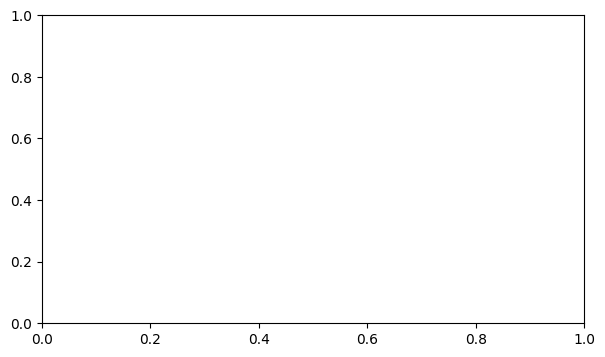

In [100]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(local_file, "r") as f:
    geo = f["geophysical_data"]
    sensor = f["sensor_band_parameters"]

    # reflectance data
    rhos = geo["rhos"][:]  # shape: [bands, lines, pixels]

    # wavelengths
    wavelengths = sensor["wavelength"][:]  # 1D array of band centers

    # pick center pixel
    ny, nx = rhos.shape[1], rhos.shape[2]
    ii, jj = ny // 2, nx // 2

    rrs_values = rhos[:, ii, jj]
    rrs_values = np.where(rrs_values < -1e3, np.nan, rrs_values)  # mask fill

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(wavelengths, rrs_values, "o-")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Rrs (sr$^{-1}$)")
plt.title("PACE OCI SFREFL Rrs Spectrum (center pixel)")
plt.grid(True)
plt.show()

In [101]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# open dataset (geophysical_data group)
dataset = xr.open_dataset(local_file, group="geophysical_data")
rrs = dataset["Rrs"]  # shape: [lines, pixels, wavelength_3d]

# pick center pixel
ny, nx = rrs.sizes["number_of_lines"], rrs.sizes["pixels_per_line"]
ii, jj = ny // 2, nx // 2

# extract spectrum at that pixel
rrs_spectrum = rrs.isel(number_of_lines=ii, pixels_per_line=jj)

# convert to sr^-1 if needed (sometimes raw values are scaled by 10000)
rrs_spectrum_values = rrs_spectrum.values / 10000.0  # comment out if already correct

# get wavelength coordinates
wavelengths = rrs_spectrum["wavelength_3d"].values

# plot spectrum
plt.figure(figsize=(7,4))
plt.plot(wavelengths, rrs_spectrum_values, "o-")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Rrs (sr$^{-1}$)")
plt.title("PACE OCI SFREFL Rrs Spectrum (center pixel)")
plt.grid(True)
plt.show()


KeyError: "No variable named 'Rrs'. Variables on the dataset include ['rhos', 'l2_flags']"

In [102]:
import earthaccess
import h5netcdf
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta

# --- Earthdata login (persist if needed) ---
auth = earthaccess.login(persist=True)

# --- Define your time and bounding box ---
argo_time = datetime(2025, 6, 8, 19, 17, 50)
dt_window = timedelta(hours=3)  # ±3h window
tspan = (
    (argo_time - dt_window).strftime("%Y-%m-%dT%H:%M:%S"),
    (argo_time + dt_window).strftime("%Y-%m-%dT%H:%M:%S")
)

lat, lon = 31.78949, -120.59814
ddeg = 1.0  # ±1° box
bbox = (lon - ddeg, lat - ddeg, lon + ddeg, lat + ddeg)

clouds = (0, 50)  # optional cloud filter

# --- Search for L2 AOP granules ---
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds
)

if len(results) == 0:
    raise ValueError("No granules found for this time and location.")

# --- Open the first granule ---
paths = earthaccess.open(results)
dataset_rrs = xr.open_dataset(paths[0], group="geophysical_data")
dataset_nav = xr.open_dataset(paths[0], group="navigation_data")

# --- Pull Rrs and coordinates ---
rrs = dataset_rrs["Rrs"]  # dims: number_of_lines, pixels_per_line, wavelength_3d
rrs = rrs.where(rrs > 0)  # mask invalid values

# Set latitude/longitude coordinates
dataset_nav = dataset_nav.set_coords(("longitude", "latitude"))
dataset_nav = dataset_nav.rename({"pixel_control_points": "pixels_per_line"})

# Merge coordinates with Rrs
rrs_ds = xr.merge((rrs, dataset_nav.coords))

# --- Subset by small bounding box around Argo location ---
lat_min, lat_max = lat - 0.05, lat + 0.05
lon_min, lon_max = lon - 0.05, lon + 0.05

rrs_box = rrs_ds["Rrs"].where(
    (rrs_ds["latitude"] > lat_min) & (rrs_ds["latitude"] < lat_max) &
    (rrs_ds["longitude"] > lon_min) & (rrs_ds["longitude"] < lon_max),
    drop=True
)

# --- Stack spatial dimensions to make 1D pixel array ---
rrs_stack = rrs_box.stack(pixel=("number_of_lines", "pixels_per_line"))

# --- Plot the Rrs spectrum for each pixel ---
plt.figure(figsize=(10, 6))
for i in range(rrs_stack.sizes["pixel"]):
    plt.plot(rrs_stack["wavelength_3d"], rrs_stack.isel(pixel=i), alpha=0.7)

plt.xlabel("Wavelength index (wavelength_3d)")
plt.ylabel("Rrs (sr⁻¹)")
plt.title("Rrs spectra near Argo profile (lat {:.3f}, lon {:.3f})".format(lat, lon))
plt.grid(True)
plt.show()

ValueError: No granules found for this time and location.

In [103]:
from datetime import timedelta

# --- Expand temporal window to ±12 hours ---
dt_window = timedelta(hours=12)
tspan = (
    (argo_time - dt_window).strftime("%Y-%m-%dT%H:%M:%S"),
    (argo_time + dt_window).strftime("%Y-%m-%dT%H:%M:%S")
)

# --- Expand spatial box to ±2 degrees ---
ddeg = 2.0
bbox = (lon - ddeg, lat - ddeg, lon + ddeg, lat + ddeg)

# --- Retry search ---
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=(0, 50)
)

print(f"Found {len(results)} granule(s)")

Found 1 granule(s)


In [104]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Open the L2 granule geophysical_data group ---
dataset_geo = xr.open_dataset(paths[0], group="geophysical_data")
rrs = dataset_geo["Rrs"]  # dimensions: number_of_lines x pixels_per_line x wavelength_3d

# --- Open navigation data for lat/lon ---
dataset_nav = xr.open_dataset(paths[0], group="navigation_data")
dataset_nav = dataset_nav.set_coords(("longitude", "latitude"))

# --- Merge Rrs with lat/lon ---
dataset = xr.merge((rrs, dataset_nav.coords))

# --- Subset by your bounding box (example) ---
rrs_box = dataset["Rrs"].where(
    (dataset["latitude"] >= bbox[1]) &
    (dataset["latitude"] <= bbox[3]) &
    (dataset["longitude"] >= bbox[0]) &
    (dataset["longitude"] <= bbox[2]),
    drop=True
)

# --- Optional: pick a single wavelength index, e.g., wavelength_3d=100 ---
rrs_map = rrs_box.sel({"wavelength_3d": 100})

# --- Plot Rrs map ---
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
rrs_map.plot(x="longitude", y="latitude", cmap="viridis", vmin=0, ax=ax)
plt.title("Rrs at wavelength index 100")
plt.show()

NameError: name 'paths' is not defined

In [105]:
import earthaccess

# Define your time, bounding box, and cloud cover
tspan = ("2025-06-01", "2025-06-30")  # example for June 2025
bbox = (-76.75, 36.97, -75.74, 39.01)
clouds = (0, 50)

# Search for L2 AOP granules
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds
)

if len(results) == 0:
    raise ValueError("No granules found for this time and location.")

# Open the first granule
paths = earthaccess.open(results)

QUEUEING TASKS | : 100%|█████████████████████████| 6/6 [00:00<00:00, 441.71it/s]
PROCESSING TASKS | : 100%|████████████████████████| 6/6 [00:01<00:00,  3.97it/s]
COLLECTING RESULTS | : 100%|███████████████████| 6/6 [00:00<00:00, 20344.24it/s]


Closest pixel: line=1708, pixel=0


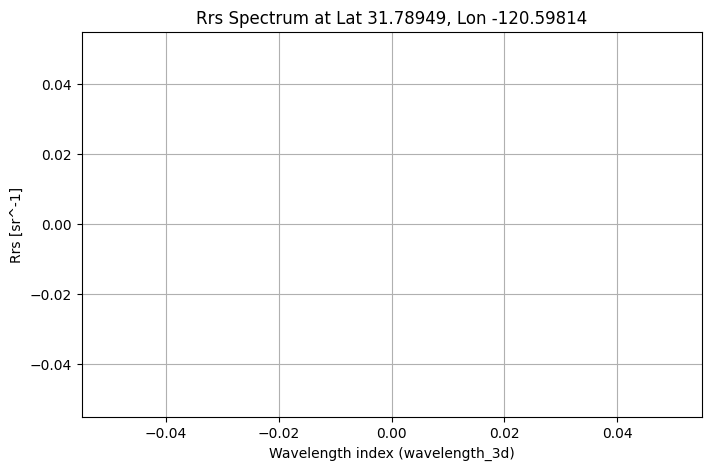

In [107]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# --- Open geophysical_data group ---
dataset_geo = xr.open_dataset(paths[0], group="geophysical_data")
rrs = dataset_geo["Rrs"]

# --- Open navigation data ---
dataset_nav = xr.open_dataset(paths[0], group="navigation_data")
lat = dataset_nav["latitude"]
lon = dataset_nav["longitude"]

# --- Find the pixel closest to your coordinates ---
target_lat = 31.78949
target_lon = -120.59814

distance = (lat - target_lat)**2 + (lon - target_lon)**2
idx = np.unravel_index(distance.argmin(), distance.shape)
line_idx, pixel_idx = idx
print(f"Closest pixel: line={line_idx}, pixel={pixel_idx}")

# --- Extract Rrs spectrum for that pixel ---
rrs_pixel = rrs.isel(number_of_lines=line_idx, pixels_per_line=pixel_idx)

# --- Mask invalid values ---
valid_min = rrs_pixel.attrs.get("valid_min", -30000)
valid_max = rrs_pixel.attrs.get("valid_max", 25000)
rrs_pixel_masked = rrs_pixel.where((rrs_pixel >= valid_min) & (rrs_pixel <= valid_max))

# --- Plot Rrs spectrum ---
plt.figure(figsize=(8,5))
plt.plot(rrs_pixel_masked.wavelength_3d, rrs_pixel_masked, marker='o')
plt.xlabel("Wavelength index (wavelength_3d)")
plt.ylabel("Rrs [sr^-1]")
plt.title(f"Rrs Spectrum at Lat {target_lat}, Lon {target_lon}")
plt.grid(True)
plt.show()

In [108]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# --- Open geophysical_data group ---
dataset_geo = xr.open_dataset(paths[0], group="geophysical_data")
rrs = dataset_geo["Rrs"]

# --- Open navigation data ---
dataset_nav = xr.open_dataset(paths[0], group="navigation_data")
lat = dataset_nav["latitude"]
lon = dataset_nav["longitude"]

# --- Define a small bounding box around your coordinates ---
lat_min = 31.78
lat_max = 31.80
lon_min = -120.60
lon_max = -120.59

# --- Subset pixels in that box ---
mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
rrs_box = rrs.where(mask, drop=True)

# --- Mask invalid Rrs values ---
valid_min = rrs.attrs.get("valid_min", -30000)
valid_max = rrs.attrs.get("valid_max", 25000)
rrs_box = rrs_box.where((rrs_box >= valid_min) & (rrs_box <= valid_max), drop=True)

# --- Stack spatial dimensions to plot all pixels ---
rrs_stack = rrs_box.stack(pixel=("number_of_lines","pixels_per_line"))

# --- Plot the Rrs spectrum ---
plt.figure(figsize=(8,5))
for i in range(rrs_stack.sizes["pixel"]):
    plt.plot(rrs_stack.wavelength_3d, rrs_stack.isel(pixel=i), alpha=0.7)

plt.xlabel("Wavelength index (wavelength_3d)")
plt.ylabel("Rrs [sr^-1]")
plt.title(f"Rrs Spectrum near Lat 31.78949, Lon -120.59814")
plt.grid(True)
plt.show()

ValueError: zero-size array to reduction operation maximum which has no identity

In [110]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Open Level 2 geophysical_data group
dataset_geo = xr.open_dataset(paths[0], group="geophysical_data")
rrs = dataset_geo["Rrs"]  # shape: [number_of_lines, pixels_per_line, wavelength_3d]

# Open navigation_data for lat/lon
dataset_nav = xr.open_dataset(paths[0], group="navigation_data")
lat = dataset_nav["latitude"]
lon = dataset_nav["longitude"]

# Merge Rrs with coordinates
rrs = rrs.assign_coords(latitude=lat, longitude=lon)

# Define bounding box around your point
lat_min, lat_max = 31.78, 31.80
lon_min, lon_max = -120.60, -120.59

# Subset Rrs in space
rrs_box = rrs.where(
    (rrs.latitude >= lat_min) & (rrs.latitude <= lat_max) &
    (rrs.longitude >= lon_min) & (rrs.longitude <= lon_max),
    drop=True
)

# Pick one wavelength index (e.g., middle wavelength)
wavelength_index = rrs_box.sizes["wavelength_3d"] // 2
rrs_plot = rrs_box.isel(wavelength_3d=wavelength_index)

# Plot
fig = plt.figure(figsize=(6,5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
rrs_plot.plot(x="longitude", y="latitude", cmap="viridis", vmin=0, ax=ax)
plt.title(f"Rrs at wavelength index {wavelength_index}")
plt.show()

ValueError: zero-size array to reduction operation maximum which has no identity

In [111]:
import earthaccess
tspan = ("2025-06-08", "2025-06-09")
bbox = (-120.65, 31.78, -120.55, 31.80)  # ~100 km² box around your point
clouds = (0, 100)

results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

if len(results) == 0:
    raise ValueError("No granules found for this time and location.")


In [112]:
from earthaccess import open
import xarray as xr

paths = open(results)
granule_path = paths[0]

QUEUEING TASKS | : 100%|█████████████████████████| 2/2 [00:00<00:00, 489.59it/s]
PROCESSING TASKS | : 100%|████████████████████████| 2/2 [00:01<00:00,  1.17it/s]
COLLECTING RESULTS | : 100%|████████████████████| 2/2 [00:00<00:00, 6915.59it/s]


In [113]:
dataset_geo = xr.open_dataset(granule_path, group="geophysical_data")
rrs = dataset_geo["Rrs"]

In [114]:
dataset_nav = xr.open_dataset(granule_path, group="navigation_data")
lat = dataset_nav["latitude"]
lon = dataset_nav["longitude"]

# Merge lat/lon into the Rrs dataset
dataset = xr.merge((rrs, lat, lon))

In [117]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# bounding box around your location
lat_min, lat_max = 31.7, 31.9
lon_min, lon_max = -120.7, -120.5

# pick one Rrs band (example: 442nm)
rrs_box = dataset["Rrs_442"].sel(
    lat=slice(lat_max, lat_min),   # note: descending lat in dataset
    lon=slice(lon_min, lon_max)
)

# plot
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()
ax.gridlines(draw_labels=True)

rrs_box.plot(ax=ax, cmap="viridis", add_colorbar=True)
plt.show()

KeyError: "No variable named 'Rrs_442'. Variables on the dataset include ['Rrs', 'latitude', 'longitude']"

In [118]:
dataset["Rrs"]


<xarray.DataArray 'Rrs' (number_of_lines: 1710, pixels_per_line: 1272,
                         wavelength_3d: 172)> Size: 1GB
[374120640 values with dtype=float32]
Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

In [119]:
# bounding box
lat_min, lat_max = 31.7, 31.9
lon_min, lon_max = -120.7, -120.5

# pick one wavelength (example: index 0)
rrs_box = dataset["Rrs"].isel(wavelength=0).sel(
    lat=slice(lat_max, lat_min),   # note descending order
    lon=slice(lon_min, lon_max)
)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()
ax.gridlines(draw_labels=True)

rrs_box.plot(ax=ax, cmap="viridis", add_colorbar=True)
plt.show()

ValueError: Dimensions {'wavelength'} do not exist. Expected one or more of ('number_of_lines', 'pixels_per_line', 'wavelength_3d')

In [120]:
# find nearest wavelength to 443 nm
target_wavelength = 443
band_index = int(abs(dataset["wavelength_3d"] - target_wavelength).argmin())

rrs_band = dataset["Rrs"].isel(wavelength_3d=band_index)

In [122]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# bounding box
lat_min, lat_max = 31.7, 31.9
lon_min, lon_max = -120.7, -120.5

# pick *any* wavelength (here the first one)
rrs_band = dataset["Rrs"].isel(wavelength_3d=0)

# subset to region
rrs_box = rrs_band.sel(
    latitude=slice(lat_max, lat_min),   # note: lat is usually descending
    longitude=slice(lon_min, lon_max)
)

# plot
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()
ax.gridlines(draw_labels=True)

rrs_box.plot(ax=ax, cmap="viridis", add_colorbar=True)
plt.show()

KeyError: "'latitude' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'number_of_lines': 1710, 'pixels_per_line': 1272})"

In [128]:
import matplotlib.pyplot as plt

# pick one wavelength band
rrs_band = dataset["Rrs"].isel(wavelength_3d=0)

plt.figure(figsize=(10,6))
plt.imshow(rrs_band, cmap="viridis")
plt.colorbar(label="Rrs (sr⁻¹)")
plt.title("Remote Sensing Reflectance 
plt.show()

SyntaxError: unterminated string literal (detected at line 9) (1998472740.py, line 9)

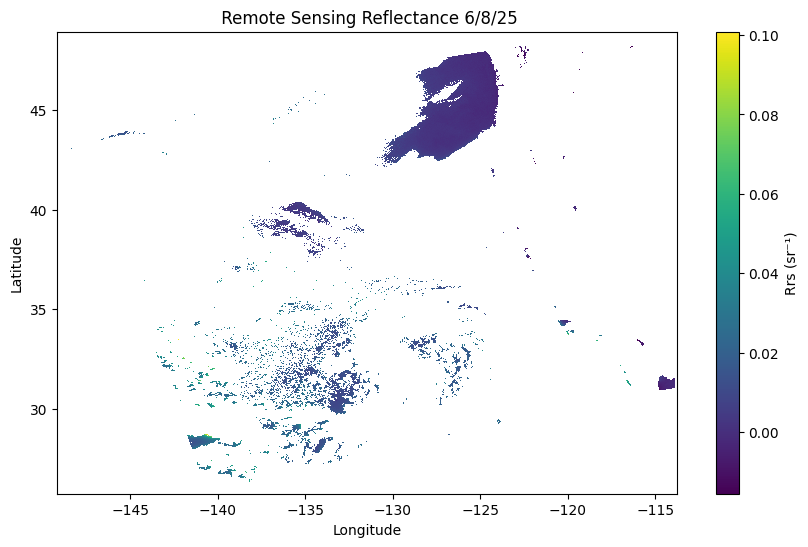

In [129]:
import matplotlib.pyplot as plt

lat = dataset["latitude"]
lon = dataset["longitude"]
rrs_band = dataset["Rrs"].isel(wavelength_3d=0)

plt.figure(figsize=(10,6))
plt.pcolormesh(lon, lat, rrs_band, cmap="viridis", shading="auto")
plt.colorbar(label="Rrs (sr⁻¹)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(" Remote Sensing Reflectance 6/8/25")
plt.show()

ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

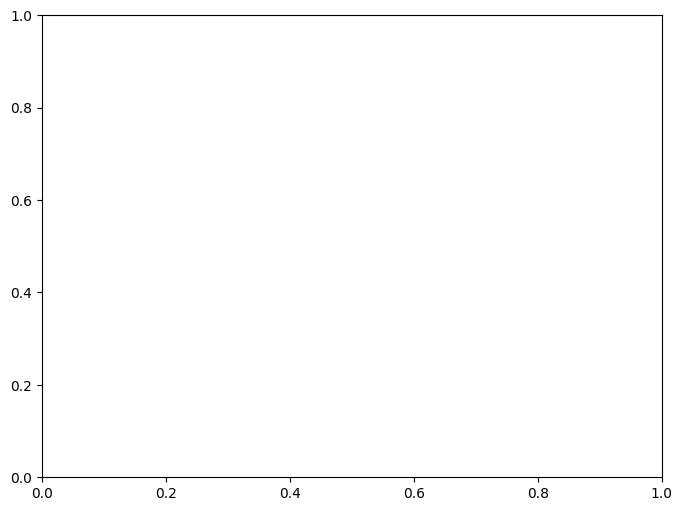

In [125]:
import matplotlib.pyplot as plt

# pick your center
lat0, lon0 = 31.78949, -120.59814
# choose a "box size" around it (e.g., ±0.5 degrees)
dlat, dlon = 0.5, 0.5  

lat = dataset["latitude"]
lon = dataset["longitude"]
rrs_band = dataset["Rrs"].isel(wavelength_3d=0)

# mask values outside the box
mask = (
    (lat >= lat0 - dlat) & (lat <= lat0 + dlat) &
    (lon >= lon0 - dlon) & (lon <= lon0 + dlon)
)

plt.figure(figsize=(8,6))
plt.pcolormesh(lon.where(mask), lat.where(mask), rrs_band.where(mask),
               cmap="viridis", shading="auto")
plt.colorbar(label="Rrs (sr⁻¹)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Rrs near {lat0:.2f}, {lon0:.2f}")
plt.show()

In [126]:
subset = rrs_band.where(mask)

plt.figure(figsize=(8,6))
subset.plot.pcolormesh(
    x="lon", y="lat", cmap="viridis", 
    cbar_kwargs={"label": "Rrs (sr⁻¹)"}
)
plt.title("Zoomed Rrs (sr⁻¹) near ROI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

ValueError: x must be one of None, 'number_of_lines', 'pixels_per_line'. Received 'lon' instead.

<Figure size 800x600 with 0 Axes>

In [127]:
print(dataset)


<xarray.Dataset> Size: 2GB
Dimensions:    (number_of_lines: 1710, pixels_per_line: 1272, wavelength_3d: 172)
Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
Data variables:
    Rrs        (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
    latitude   (number_of_lines, pixels_per_line) float32 9MB 25.77 ... 48.91
    longitude  (number_of_lines, pixels_per_line) float32 9MB -140.6 ... -115.1
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000


In [130]:
# Look at all global attributes
dataset.attrs.keys()

dict_keys(['long_name', 'units', 'standard_name', 'valid_min', 'valid_max'])

In [131]:
print("Start time:", dataset.attrs.get("time_coverage_start"))
print("End time:", dataset.attrs.get("time_coverage_end"))

Start time: None
End time: None


In [132]:
dataset["time"]


KeyError: "No variable named 'time'. Variables on the dataset include ['Rrs', 'latitude', 'longitude']"